![](Rydiqule_Logo_Transparent_300.png)

In [1]:
%matplotlib inline

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R

In [4]:
import rydiqule as rq
from rydiqule.sensor_utils import get_rho_ij

In [63]:
atom = "Rb85"
(g, e) = rq.D2_states(atom)
r1 = rq.A_QState(55, 2, 2.5)
r2 = rq.A_QState(55, 3, 3.5)

In [105]:
kunit1 = np.array([1,0,0])
kunit2 = np.array([-1,0,0])
detunings = np.linspace(-200,200,100)
red_laser = {'states':(g,e), 'rabi_frequency':2*np.pi*np.array([5,10,15,20]), 'detuning':0,  'kunit': kunit1}
blue_laser = {'states':(e,r1), 'rabi_frequency':2*np.pi*4, 'detuning': detunings, 'kunit': kunit2}


RbSensor_ss = rq.Cell(atom, [g, e, r1],
                      gamma_transit=2*np.pi*1, cell_length = 0.01)

In [106]:
RbSensor_ss.add_couplings(red_laser,blue_laser)

In [107]:
dop_mesh_method = {'method': 'split',
                   'width_doppler': 2.0,
                   'n_doppler': 201,
                   'width_coherent': 0.28,
                   'n_coherent': 1001}
sols = rq.solve_steady_state(RbSensor_ss, doppler=True, doppler_mesh_method=dop_mesh_method)

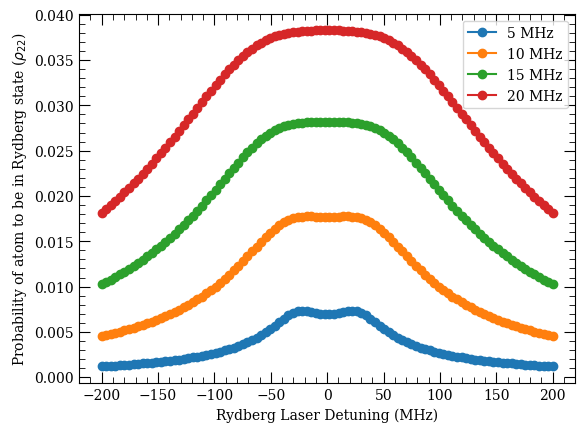

In [117]:
fig, ax = plt.subplots()
#ax.plot(detunings, np.transpose(get_rho_ij(sols.rho,2,2)[0,:]), '-o', label ="5MHz")
ax.plot(detunings, np.transpose(get_rho_ij(sols.rho,2,2)), '-o', label =('5 MHz','10 MHz','15 MHz','20 MHz'))
ax.set_xlabel("Rydberg Laser Detuning (MHz)")
ax.set_ylabel(r"Probability of atom to be in Rydberg state ($\rho_{22}$)")
ax.legend()